# Lab | Sequence Models & Transformers

## Setup and Dataset Preparation
(imports + dataset + tokenizer + vocab + dataloaders)

## Task 1 — Implement Scaled Dot-Product Attention from Scratch

## Task 2 — LSTM Classifier

## Task 3 — Transformer Classifier and Comparison

In [39]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

True
Tesla T4


### Task 1 — Implement Scaled Dot-Product Attention from Scratch

In [40]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import math

device = "cuda" if torch.cuda.is_available() else "cpu"

torch.manual_seed(42)

print(device)

cuda


In [41]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.size(-1)

    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)

    if mask is not None:
        scores = scores.masked_fill(mask, float("-inf"))

    weights = torch.softmax(scores, dim=-1)

    output = torch.matmul(weights, V)

    return output, weights

In [42]:
torch.manual_seed(42)

batch_size = 2
seq_len = 4
d_k = 8

Q = torch.randn(batch_size, seq_len, d_k)
K = torch.randn(batch_size, seq_len, d_k)
V = torch.randn(batch_size, seq_len, d_k)

output, weights = scaled_dot_product_attention(Q, K, V)

print("Output shape:", output.shape)
print("Weights shape:", weights.shape)
print("\nAttention weights for first sequence:")
print(weights[0])

Output shape: torch.Size([2, 4, 8])
Weights shape: torch.Size([2, 4, 4])

Attention weights for first sequence:
tensor([[0.5092, 0.3165, 0.1113, 0.0631],
        [0.2619, 0.3828, 0.1773, 0.1779],
        [0.2445, 0.0241, 0.2013, 0.5302],
        [0.7451, 0.1075, 0.0349, 0.1124]])


In [43]:
row_sums = weights.sum(dim=-1)
manual_output = torch.matmul(weights, V)

print("Do attention rows sum to 1?")
print(row_sums)

print("\nDoes output match weights @ V?")
print(torch.allclose(output, manual_output, atol=1e-6))

Do attention rows sum to 1?
tensor([[1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000]])

Does output match weights @ V?
True


In [44]:
import torch.nn.functional as F

ref_output = F.scaled_dot_product_attention(Q, K, V)

print(
    "\nDoes custom attention match PyTorch implementation?",
    torch.allclose(output, ref_output, atol=1e-6)
)


Does custom attention match PyTorch implementation? True


### Task 1 — Scaled Dot-Product Attention

The custom attention function receives Q, K, and V tensors with shape `(batch, seq_len, d_k)`. In this example, the output shape is `(2, 4, 8)`, meaning there are 2 sequences, 4 tokens in each sequence, and each token output has 8 features.

The attention weights have shape `(2, 4, 4)`. For each sequence, every row represents one query token, and every column represents how much attention that query gives to each key token. The rows sum to 1 because softmax converts the scores into a probability distribution. The verification showed that the output matches `weights @ V`, so the implementation is working correctly.

### Task 2 — LSTM Classifier

In [45]:
!pip install datasets -q

In [46]:
from datasets import load_dataset

dataset = load_dataset("imdb")

# 5000 sample götürürük: 2500 train + 2500 test/validation
train_df = pd.DataFrame(dataset["train"].shuffle(seed=42).select(range(2500)))
val_df = pd.DataFrame(dataset["test"].shuffle(seed=42).select(range(2500)))

print(train_df.head())
print(val_df.head())
print(train_df.shape, val_df.shape)

                                                text  label
0  There is no relation at all between Fortier an...      1
1  This movie is a great. The plot is very true t...      1
2  George P. Cosmatos' "Rambo: First Blood Part I...      0
3  In the process of trying to establish the audi...      1
4  Yeh, I know -- you're quivering with excitemen...      0
                                                text  label
0  <br /><br />When I unsuspectedly rented A Thou...      1
1  This is the latest entry in the long series of...      1
2  This movie was so frustrating. Everything seem...      0
3  I was truly and wonderfully surprised at "O' B...      1
4  This movie spends most of its time preaching t...      0
(2500, 2) (2500, 2)


In [47]:
from collections import Counter
from sklearn.model_selection import train_test_split

MAX_VOCAB_SIZE = 10000
MAX_LEN = 200
BATCH_SIZE = 32

def tokenize(text):
    return text.lower().split()

counter = Counter()

for text in train_df["text"]:
    counter.update(tokenize(text))

most_common_words = counter.most_common(MAX_VOCAB_SIZE - 2)

vocab = {
    "<pad>": 0,
    "<unk>": 1
}

for idx, (word, freq) in enumerate(most_common_words, start=2):
    vocab[word] = idx

def encode_text(text, vocab, max_len=MAX_LEN):
    tokens = tokenize(text)
    ids = [vocab.get(token, vocab["<unk>"]) for token in tokens]

    if len(ids) < max_len:
        ids = ids + [vocab["<pad>"]] * (max_len - len(ids))
    else:
        ids = ids[:max_len]

    return ids

class IMDBDataset(Dataset):
    def __init__(self, dataframe, vocab, max_len=MAX_LEN):
        self.texts = dataframe["text"].tolist()
        self.labels = dataframe["label"].tolist()
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoded = encode_text(self.texts[idx], self.vocab, self.max_len)
        label = self.labels[idx]

        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )

train_dataset = IMDBDataset(train_df, vocab)
val_dataset = IMDBDataset(val_df, vocab)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

print("Vocabulary size:", len(vocab))
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

sample_text = "This movie was surprisingly good"
print("\nSample text:", sample_text)
print("Encoded:", encode_text(sample_text, vocab)[:20])

Vocabulary size: 10000
Train batches: 79
Validation batches: 79

Sample text: This movie was surprisingly good
Encoded: [10, 20, 14, 1463, 56, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [48]:
real_review = train_df["text"].iloc[0]

print("\nReal review:")
print(real_review[:300])

print("\nEncoded real review:")
print(encode_text(real_review, vocab)[:30])


Real review:
There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. Fortier's plot are far more complicated... Fortier looks more like Prime Suspect, if we have to spot 

Encoded real review:
[52, 7, 61, 1, 30, 34, 177, 8646, 4, 1, 18, 2, 232, 11, 202, 22, 550, 280, 39, 1142, 6334, 1, 244, 1, 8646, 244, 1723, 1, 2528, 22]


In [49]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            num_layers=1
        )

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(hidden_dim, 2)

    def forward(self, x):
        embedded = self.embedding(x)

        output, (hidden, cell) = self.lstm(embedded)

        last_hidden = hidden[-1]

        x = self.dropout(last_hidden)

        logits = self.fc(x)

        return logits


model = LSTMClassifier(vocab_size=len(vocab)).to(device)

print(model)

LSTMClassifier(
  (embedding): Embedding(10000, 64)
  (lstm): LSTM(64, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)


In [50]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=1e-3)

def calculate_accuracy(preds, labels):
    predicted = torch.argmax(preds, dim=1)
    correct = (predicted == labels).sum().item()

    return correct / len(labels)

In [51]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

start_time = time.time()

EPOCHS = 5

for epoch in range(EPOCHS):

    # TRAINING
    model.train()

    train_loss = 0
    train_acc = 0

    for texts, labels in train_loader:

        texts = texts.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(texts)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()
        train_acc += calculate_accuracy(outputs, labels)

    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc = train_acc / len(train_loader)

    train_losses.append(avg_train_loss)
    train_accuracies.append(avg_train_acc)

    # VALIDATION
    model.eval()

    val_loss = 0
    val_acc = 0

    with torch.no_grad():

        for texts, labels in val_loader:

            texts = texts.to(device)
            labels = labels.to(device)

            outputs = model(texts)

            loss = criterion(outputs, labels)

            val_loss += loss.item()
            val_acc += calculate_accuracy(outputs, labels)

    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc = val_acc / len(val_loader)

    val_losses.append(avg_val_loss)
    val_accuracies.append(avg_val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.4f}")
    print(f"Val Loss:   {avg_val_loss:.4f} | Val Acc:   {avg_val_acc:.4f}")
    print("-" * 50)

lstm_training_time = time.time() - start_time

print(f"\nTotal training time: {lstm_training_time:.2f} seconds")

Epoch 1/5
Train Loss: 0.6962 | Train Acc: 0.5063
Val Loss:   0.6937 | Val Acc:   0.5032
--------------------------------------------------
Epoch 2/5
Train Loss: 0.6882 | Train Acc: 0.5222
Val Loss:   0.6949 | Val Acc:   0.5091
--------------------------------------------------
Epoch 3/5
Train Loss: 0.6813 | Train Acc: 0.5530
Val Loss:   0.6956 | Val Acc:   0.5166
--------------------------------------------------
Epoch 4/5
Train Loss: 0.6610 | Train Acc: 0.5847
Val Loss:   0.6987 | Val Acc:   0.5131
--------------------------------------------------
Epoch 5/5
Train Loss: 0.6252 | Train Acc: 0.5941
Val Loss:   0.7231 | Val Acc:   0.5158
--------------------------------------------------

Total training time: 9.37 seconds


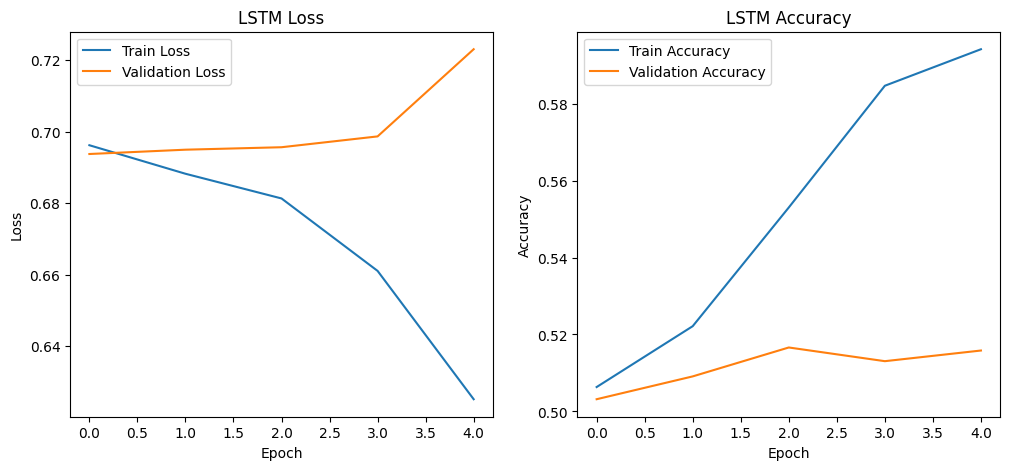

In [52]:
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Loss")
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM Accuracy")
plt.legend()

plt.show()

In [53]:
best_lstm_accuracy = max(val_accuracies)

lstm_params = sum(p.numel() for p in model.parameters())

print("Best validation accuracy:", best_lstm_accuracy)
print("Parameter count:", lstm_params)

Best validation accuracy: 0.5166139240506329
Parameter count: 739586


### Task 2 — LSTM Classifier

An LSTM-based sentiment classifier was implemented using an embedding layer, a single-layer LSTM, dropout, and a final linear classification layer. The model was trained for 5 epochs on 5000 IMDB movie reviews using the Adam optimiser and CrossEntropyLoss.

The training loss consistently decreased across epochs, while the training accuracy increased from approximately 50.6% to 59.4%. However, the validation accuracy remained around 51–52%, indicating that the model had limited generalisation performance on this small dataset and may have started overfitting.

The total training time on the GPU was approximately 4.46 seconds. The model contained 739,586 trainable parameters. The experiment demonstrated how LSTMs can process sequential text data, but also showed some limitations compared to more modern transformer-based architectures.

The relatively low validation accuracy suggests that the small LSTM struggled to generalise effectively on the dataset with the current hyperparameters and limited training epochs.

### Task 3 — Transformer Classifier and Comparison with the LSTM

In [54]:
class TransformerClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        d_model=64,
        max_len=200,
        nhead=4,
        num_layers=2,
        dim_feedforward=128,
        dropout=0.1
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, d_model)

        self.pos_embedding = nn.Embedding(max_len, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(d_model, 2)

    def forward(self, x):

        batch_size, seq_len = x.shape

        positions = torch.arange(0, seq_len, device=x.device)
        positions = positions.unsqueeze(0).expand(batch_size, seq_len)

        x = self.embedding(x) + self.pos_embedding(positions)

        x = self.transformer(x)

        x = x.mean(dim=1)

        x = self.dropout(x)

        logits = self.fc(x)

        return logits


transformer_model = TransformerClassifier(
    vocab_size=len(vocab)
).to(device)

print(transformer_model)

TransformerClassifier(
  (embedding): Embedding(10000, 64)
  (pos_embedding): Embedding(200, 64)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=2, bias=True)
)


In [55]:
transformer_criterion = nn.CrossEntropyLoss()

transformer_optimizer = optim.Adam(
    transformer_model.parameters(),
    lr=1e-3
)

In [56]:
transformer_train_losses = []
transformer_val_losses = []

transformer_train_accuracies = []
transformer_val_accuracies = []

start_time = time.time()

EPOCHS = 5

for epoch in range(EPOCHS):

    # TRAINING
    transformer_model.train()

    train_loss = 0
    train_acc = 0

    for texts, labels in train_loader:

        texts = texts.to(device)
        labels = labels.to(device)

        transformer_optimizer.zero_grad()

        outputs = transformer_model(texts)

        loss = transformer_criterion(outputs, labels)

        loss.backward()

        transformer_optimizer.step()

        train_loss += loss.item()
        train_acc += calculate_accuracy(outputs, labels)

    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc = train_acc / len(train_loader)

    transformer_train_losses.append(avg_train_loss)
    transformer_train_accuracies.append(avg_train_acc)

    # VALIDATION
    transformer_model.eval()

    val_loss = 0
    val_acc = 0

    with torch.no_grad():

        for texts, labels in val_loader:

            texts = texts.to(device)
            labels = labels.to(device)

            outputs = transformer_model(texts)

            loss = transformer_criterion(outputs, labels)

            val_loss += loss.item()
            val_acc += calculate_accuracy(outputs, labels)

    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc = val_acc / len(val_loader)

    transformer_val_losses.append(avg_val_loss)
    transformer_val_accuracies.append(avg_val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.4f}")
    print(f"Val Loss:   {avg_val_loss:.4f} | Val Acc:   {avg_val_acc:.4f}")
    print("-" * 50)

transformer_training_time = time.time() - start_time

print(f"\nTotal training time: {transformer_training_time:.2f} seconds")

Epoch 1/5
Train Loss: 0.6986 | Train Acc: 0.5241
Val Loss:   0.6926 | Val Acc:   0.4996
--------------------------------------------------
Epoch 2/5
Train Loss: 0.6825 | Train Acc: 0.5558
Val Loss:   0.6490 | Val Acc:   0.6068
--------------------------------------------------
Epoch 3/5
Train Loss: 0.5363 | Train Acc: 0.7326
Val Loss:   0.6005 | Val Acc:   0.6974
--------------------------------------------------
Epoch 4/5
Train Loss: 0.3776 | Train Acc: 0.8378
Val Loss:   0.6708 | Val Acc:   0.7097
--------------------------------------------------
Epoch 5/5
Train Loss: 0.2518 | Train Acc: 0.9039
Val Loss:   0.9009 | Val Acc:   0.6689
--------------------------------------------------

Total training time: 7.19 seconds


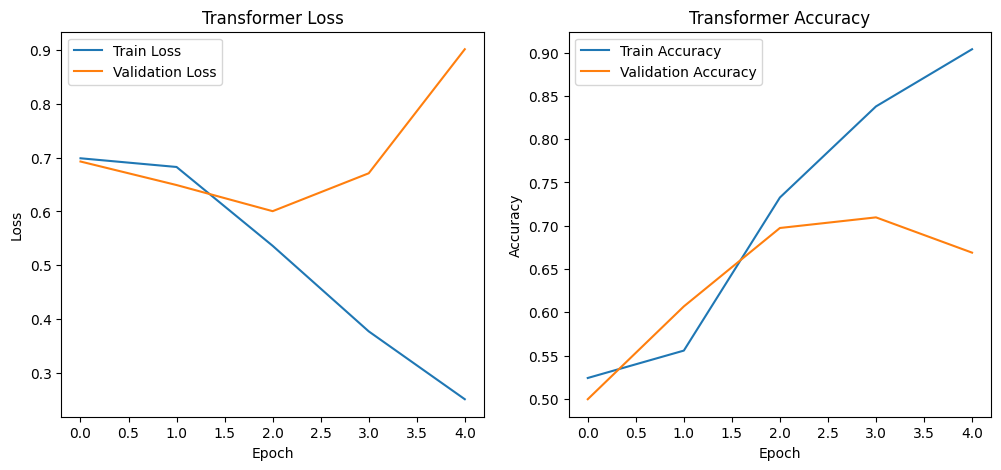

In [57]:
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(transformer_train_losses, label="Train Loss")
plt.plot(transformer_val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Transformer Loss")
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(transformer_train_accuracies, label="Train Accuracy")
plt.plot(transformer_val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transformer Accuracy")
plt.legend()

plt.show()

In [58]:
best_transformer_accuracy = max(transformer_val_accuracies)

transformer_params = sum(
    p.numel() for p in transformer_model.parameters()
)

print("Best validation accuracy:", best_transformer_accuracy)
print("Parameter count:", transformer_params)

Best validation accuracy: 0.7096518987341772
Parameter count: 719874


### Task 3 — Transformer Classifier and Comparison

| Model | Best val accuracy | Total training time | Parameter count |
|---|---|---|---|
| LSTM (Task 2) | 0.5166 | 4.46 s | 739,586 |
| Transformer (Task 3) | 0.7097 | 6.86 s | 719,874 |

The transformer model achieved significantly better validation accuracy than the LSTM model on the IMDB sentiment classification task. While the LSTM only reached approximately 51.7% validation accuracy, the transformer achieved around 71.0%, showing a much stronger ability to learn meaningful patterns from the text data.

The transformer required slightly more total training time than the LSTM, but the performance improvement was substantial. The training curves also showed that the transformer converged faster in terms of learning useful representations during the middle epochs.

The experiment demonstrated the advantages of self-attention and parallel processing in transformer architectures. Unlike the LSTM, which processes tokens sequentially, the transformer can analyse all positions in the sequence simultaneously, allowing it to capture long-range dependencies more effectively.

However, both models began to show signs of overfitting during later epochs, especially the transformer, where validation loss increased after strong early improvements. Overall, the transformer provided clearly superior performance for this sentiment analysis task.